This code reads the global create in RG_Lee and visualize the data

In [2]:
import numpy as np  # numerical library
import xarray as xr  # netCDF library
import pandas as pd

import matplotlib.pyplot as plt  # plotting library
import matplotlib.ticker as mticker
from matplotlib.dates import DateFormatter


import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature

import cftime
import locale 

# Some defaults:
plt.rcParams['figure.figsize'] = (12, 5)  # Default plot size
locale.setlocale(locale.LC_TIME, "es_ES");

In [3]:
#To compute de climatoloy
yearC1='2004'
yearC2='2008'

## Read the data

In [4]:
DC=xr.open_dataset('/Users/pvb/Dropbox/Oceanografia/Analisis/ComparisonClimatologies/Data/RG_Global_2004-01_2025-08.nc')

In [5]:
DC_temp=DC.temperature.sel(lat=slice( -90, 90))
DC_salt=DC.salinity.sel(lat=slice( -90, 90))

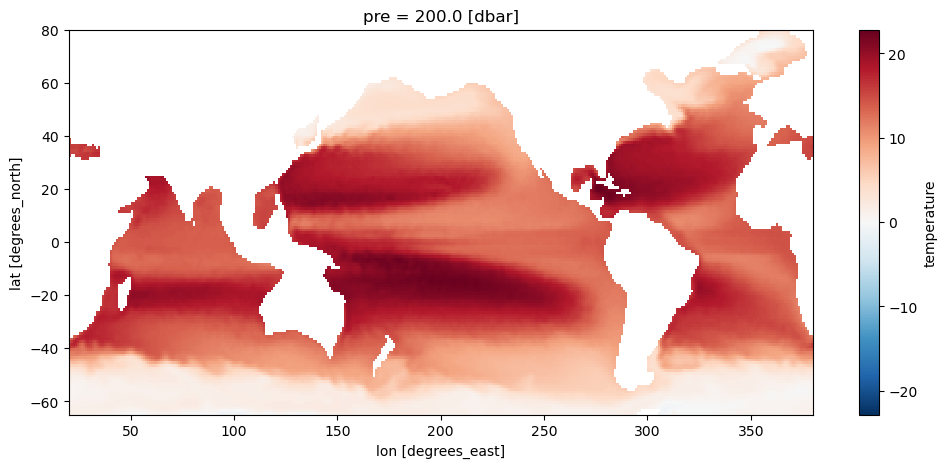

In [6]:
DC_temp.mean('time').sel(pre=200, method='nearest').plot();

## Seasonal cycle
Create seasonal climatology from 2004 to 2014 and the asociated anomaly

In [7]:
#Create monthly climatology
DC_temp_clim = DC_temp.sel(time=slice(yearC1,yearC2)).groupby('time.month').mean(dim='time').load();
DC_salt_clim = DC_salt.sel(time=slice(yearC1,yearC2)).groupby('time.month').mean(dim='time').load();

#Create anomaly
DC_temp_anom = DC_temp.groupby('time.month') - DC_temp_clim
DC_temp_anom.load();

DC_salt_anom = DC_salt.groupby('time.month') - DC_salt_clim
DC_salt_anom.load();

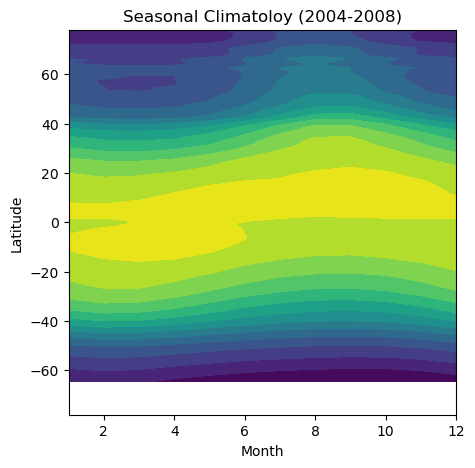

In [8]:
fig, ax = plt.subplots(1, 1 , figsize=(5,5))
ax.contourf(DC_temp_clim.mean(dim='lon').sel(pre=10, method='nearest').month,
                 DC_temp_clim.mean(dim='lon').sel(pre=10, method='nearest').lat,
                 DC_temp_clim.mean(dim='lon').sel(pre=10, method='nearest').transpose(),
            levels=12, vmin=-2, vmax=30)
ax.set_ylim(-78,78)
ax.grid()
ax.set_title('Seasonal Climatoloy (' + yearC1 + '-' + yearC2 + ')')
ax.set_ylabel('Latitude') 
ax.set_xlabel('Month')
ax.grid()

# Weighted in Lat

In [9]:
weights = np.cos(np.deg2rad(DC.temperature.lat))
weights.name = "weights"
DC_temp_weighted = DC_temp.weighted(weights)
DC_salt_weighted = DC_salt.weighted(weights)

DC_temp_anom_weighted = DC_temp_anom.weighted(weights)
DC_salt_anom_weighted = DC_salt_anom.weighted(weights)

In [10]:
DC_temp_LLwmean = DC_temp_weighted.mean(("lon", "lat"),skipna=True).load()
DC_salt_LLwmean = DC_salt_weighted.mean(("lon", "lat"),skipna=True).load()

DC_temp_anom_LLwmean = DC_temp_anom_weighted.mean(("lon", "lat"),skipna=True).load()
DC_salt_anom_LLwmean = DC_salt_anom_weighted.mean(("lon", "lat"),skipna=True).load()

### smoothed versions

In [11]:
DC_temp_LLwmean_rolling = DC_temp_LLwmean.rolling(time=12,center=True).mean()
DC_salt_LLwmean_rolling = DC_salt_LLwmean.rolling(time=12,center=True).mean()

DC_temp_anom_LLwmean_rolling = DC_temp_anom_LLwmean.rolling(time=12,center=True).mean()
DC_salt_anom_LLwmean_rolling = DC_salt_anom_LLwmean.rolling(time=12,center=True).mean()

### Times series of mean values, and anomalies,  at selected levels,

## Global mean

### Weigth in pres

In [12]:
# Create weigths in Pre
pre = DC_temp.pre
delta_p = pre.diff('pre')
delta_p = delta_p.reindex(pre=pre, method='ffill')
delta_p.name = 'pre_weights'
delta_p[0]=5
delta_p[1]=10
delta_p[-1]=100
weightsPre=delta_p/delta_p.sum()

In [13]:
DC_temp_PLLwmean_2000dbar=DC_temp_LLwmean.weighted(weightsPre).mean("pre")
DC_temp_anom_PLLwmean_2000dbar=DC_temp_anom_LLwmean.weighted(weightsPre).mean("pre")


DC_salt_PLLwmean_2000dbar=DC_salt_LLwmean.weighted(weightsPre).mean("pre")
DC_salt_anom_PLLwmean_2000dbar=DC_salt_anom_LLwmean.weighted(weightsPre).mean("pre")


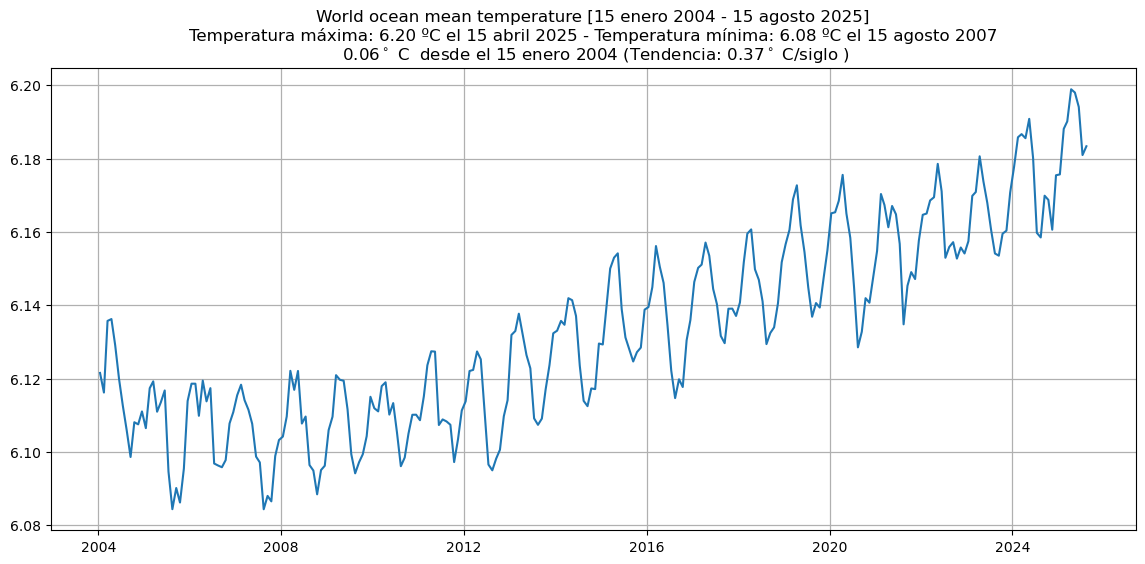

In [14]:
Tseries=DC_temp_PLLwmean_2000dbar
TituloFigura='World ocean mean temperature'

tmax = Tseries.isel(Tseries.argmax(...))
tmin = Tseries.isel(Tseries.argmin(...))

d_tmax = Tseries.time.isel(Tseries.argmax(...))
d_tmin = Tseries.time.isel(Tseries.argmin(...))

z = np.polyfit(Tseries.time.astype(np.int64),Tseries, 1)
linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
Dslope=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo


fig, ax = plt.subplots(figsize = (14,6))
ax.plot(Tseries.time,Tseries)
ax.grid(linestyle='-', linewidth=.9)

#Linear fit

tTActual = Tseries.time[-1].dt.strftime("%d %B %Y").values + " %2.2f $^\\circ$C "%(Tseries[-1].values)
tTMaxima =  'Temperatura máxima: ' + "%2.2f ºC"%(tmax) + ' el ' + d_tmax.dt.strftime("%d %B %Y").values
tTMinima =  'Temperatura mínima: ' + "%2.2f ºC"%(tmin) + ' el ' + d_tmin.dt.strftime("%d %B %Y").values
tPeriodo =  " [" + Tseries.time[0].dt.strftime("%d %B %Y").values + " - "+ Tseries.time[-1].dt.strftime("%d %B %Y").values + "]"
tTendencia =  "\n %2.2f$^\\circ$ C "%(Tseries[-1]-Tseries[0]) + ' desde el ' + Tseries.time[0].dt.strftime("%d %B %Y").values + " (Tendencia: " + "%2.2f"%(Dslope) + "$^\\circ$ C/siglo )"

ax.set_title(TituloFigura + tPeriodo + '\n' + tTMaxima + ' - ' + tTMinima + tTendencia);


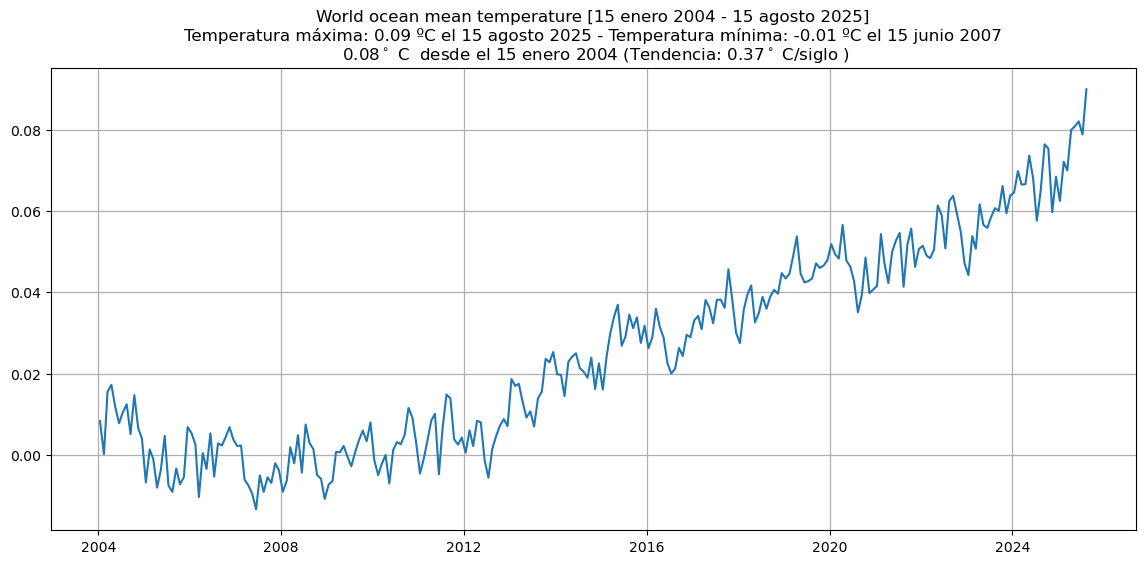

In [15]:
Tseries=DC_temp_anom_PLLwmean_2000dbar
TituloFigura='World ocean mean temperature'

tmax = Tseries.isel(Tseries.argmax(...))
tmin = Tseries.isel(Tseries.argmin(...))

d_tmax = Tseries.time.isel(Tseries.argmax(...))
d_tmin = Tseries.time.isel(Tseries.argmin(...))

#Linear fit
z = np.polyfit(Tseries.time.astype(np.int64),Tseries, 1)
linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
Dslope=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo


fig, ax = plt.subplots(figsize = (14,6))
ax.plot(Tseries.time,Tseries)
ax.grid(linestyle='-', linewidth=.9)

tTActual = Tseries.time[-1].dt.strftime("%d %B %Y").values + " %2.2f $^\\circ$C "%(Tseries[-1].values)
tTMaxima =  'Temperatura máxima: ' + "%2.2f ºC"%(tmax) + ' el ' + d_tmax.dt.strftime("%d %B %Y").values
tTMinima =  'Temperatura mínima: ' + "%2.2f ºC"%(tmin) + ' el ' + d_tmin.dt.strftime("%d %B %Y").values
tPeriodo =  " [" + Tseries.time[0].dt.strftime("%d %B %Y").values + " - "+ Tseries.time[-1].dt.strftime("%d %B %Y").values + "]"
tTendencia =  "\n %2.2f$^\\circ$ C "%(Tseries[-1]-Tseries[0]) + ' desde el ' + Tseries.time[0].dt.strftime("%d %B %Y").values + " (Tendencia: " + "%2.2f"%(Dslope) + "$^\\circ$ C/siglo )"

ax.set_title(TituloFigura + tPeriodo + '\n' + tTMaxima + ' - ' + tTMinima + tTendencia);


In [16]:
Posiciones=[(0.10, 0.65, 0.8, 0.22),
            (0.10, 0.48, 0.8, 0.165),
            (0.10, 0.10, 0.8, 0.378)]


<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\c'
/var/folders/tj/cj2twzcd30jbzn574lsp6phw0000gn/T/ipykernel_9232/641462606.py:12: SyntaxWarning: invalid escape sequence '\c'
  tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"
/var/folders/tj/cj2twzcd30jbzn574lsp6phw0000gn/T/ipykernel_9232/641462606.py:30: SyntaxWarning: invalid escape sequence '\c'
  tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"
/var/folders/tj/cj2twzcd30jbzn574lsp6phw0000gn/T/ipykernel_9232/641462606.py:44: SyntaxWarning: invalid escape sequence '\c'
  tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"


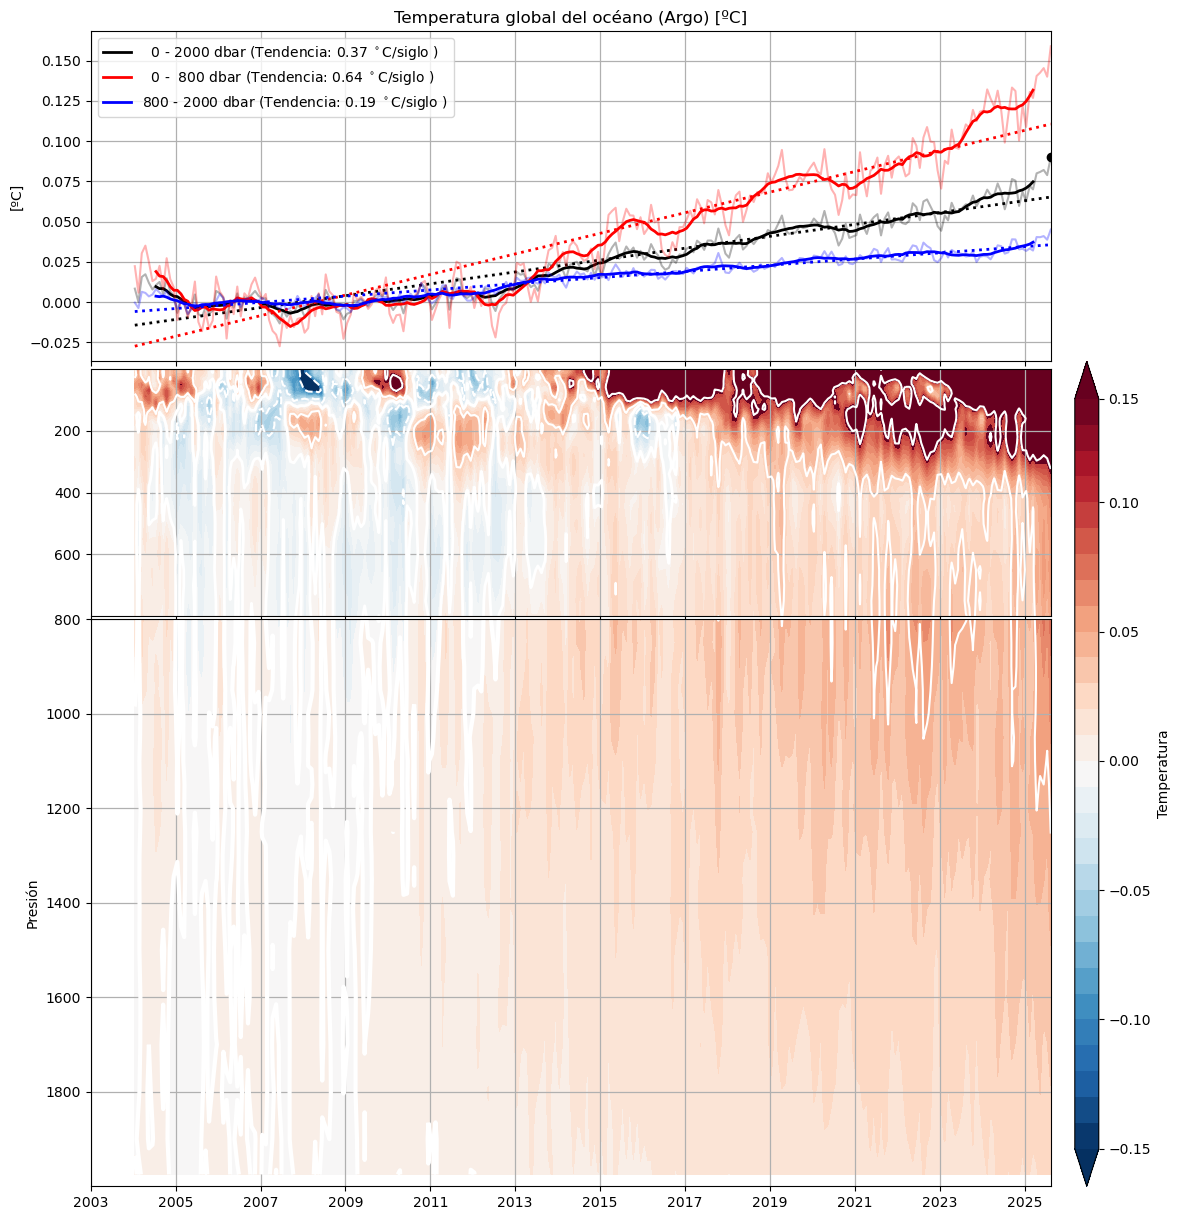

In [17]:
Tseries=DC_temp_anom_LLwmean
Tseries_rolling=DC_temp_anom_LLwmean_rolling

fig, ax = plt.subplots(3,1,figsize = (12,15),sharex=True)

# Mean values
#0-2000m
z = np.polyfit(Tseries.time.astype(np.int64),
               Tseries.sel(pre=slice(0,2000)).weighted(weightsPre).mean("pre"), 1)
linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
Dslope=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo
tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"


ax[0].plot(Tseries.time,Tseries.sel(pre=slice(0,2000)).weighted(weightsPre).mean("pre"),
           color='k',alpha=0.3)
ax[0].plot(Tseries_rolling.time,Tseries_rolling.sel(pre=slice(0,2000)).weighted(weightsPre).mean("pre"),
           linewidth=2,color='k',  label= '  0 - 2000 dbar'+tTendencia)
ax[0].plot(Tseries.time[-1],Tseries.sel(pre=slice(0,2000)).weighted(weightsPre).mean("pre")[-1],
           'ko')
ax[0].plot(Tseries.time,linearf,'k:',linewidth=2);



#0-800m
z = np.polyfit(Tseries.time.astype(np.int64),
               Tseries.sel(pre=slice(0,800)).weighted(weightsPre).mean("pre"), 1)
linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
Dslope=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo
tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"

ax[0].plot(Tseries.time,Tseries.sel(pre=slice(0,800)).weighted(weightsPre).mean("pre"),
           color='r',alpha=0.3)
ax[0].plot(Tseries_rolling.time,Tseries_rolling.sel(pre=slice(0,800)).weighted(weightsPre).mean("pre"),
           linewidth=2,color='r',  label= '  0 -  800 dbar'+tTendencia )
ax[0].plot(Tseries.time,linearf,'r:',linewidth=2);


#800-2000m
z = np.polyfit(Tseries.time.astype(np.int64),
               Tseries.sel(pre=slice(800,2000)).weighted(weightsPre).mean("pre"), 1)
linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
Dslope=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo
tTendencia =  " (Tendencia: " + "%2.2f"%(Dslope) + " $^\circ$C/siglo )"

ax[0].plot(Tseries.time,Tseries.sel(pre=slice(800,2000)).weighted(weightsPre).mean("pre"),
           color='b',alpha=0.3)
ax[0].plot(Tseries_rolling.time,Tseries_rolling.sel(pre=slice(800,2000)).weighted(weightsPre).mean("pre"),
           linewidth=2,color='b',label= '800 - 2000 dbar'+tTendencia)
ax[0].plot(Tseries.time,linearf,'b:',linewidth=2);

ax[0].grid(linestyle='-', linewidth=.9)
ax[0].set_position(Posiciones[0])
ax[0].legend()
ax[0].set_ylabel('[ºC]')
ax[0].set_title('Temperatura global del océano (Argo) [ºC]')

## Upper contour

ax[1].contour(Tseries.time, Tseries.sel(pre=slice(0,800)).pre, Tseries.sel(pre=slice(0,800)).transpose(),
              colors='w',
              levels=[-0.15, -0.05, 0.05, 0.15] )

ax[1].contour(Tseries.time, Tseries.sel(pre=slice(0,800)).pre, Tseries.sel(pre=slice(0,800)).transpose(),
              colors='w', linewidths=2,
              levels=[0] )

ax[1].contourf(Tseries.time, Tseries.sel(pre=slice(0,800)).pre, Tseries.sel(pre=slice(0,800)).transpose(),
                cmap='RdBu_r',levels=np.arange(-0.15,0.15,0.01),extend='both',vmin=-0.2, vmax=0.2)
ax[1].set_ylim(0,800)
ax[1].invert_yaxis()
ax[1].set_yticks([200,400,600])
ax[1].grid(linestyle='-', linewidth=.9)
ax[1].set_position(Posiciones[1])

ax[2].contour(Tseries.time, Tseries.sel(pre=slice(800,2000)).pre, Tseries.sel(pre=slice(800,2000)).transpose(),
              colors='w',
              levels=[-0.05,0.05] )

ax[2].contour(Tseries.time, Tseries.sel(pre=slice(800,2000)).pre, Tseries.sel(pre=slice(800,2000)).transpose(),
              colors='w', linewidths=3,
              levels=[0] )

cntr2 = ax[2].contourf(Tseries.time, Tseries.sel(pre=slice(800,2000)).pre,
                       Tseries.sel(pre=slice(800,2000)).transpose(),
                       cmap='RdBu_r',levels=np.arange(-0.15,0.15,0.01),extend='both')

ax[2].set_ylim(800,2000)
ax[2].invert_yaxis()
ax[2].set_yticks([800,1000,1200,1400,1600,1800])
ax[2].grid(linestyle='-', linewidth=.9)
ax[2].set_position(Posiciones[2])
ax[2].set_ylabel('Presión')

# Adding the colorbar
cbaxes = fig.add_axes([0.92, 0.1, 0.02, 0.55])  
cb = fig.colorbar(cntr2, cax=cbaxes);
cbaxes.set_yticks([-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15])
cbaxes.set_ylabel('Temperatura')

# xtick Labels
ax[0].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));
ax[1].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));
ax[2].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));

ax[2].set_xticklabels(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN').strftime('%Y'));

fig.savefig("Poster_GlobalRGAnalisis_TSection.svg", format="svg")

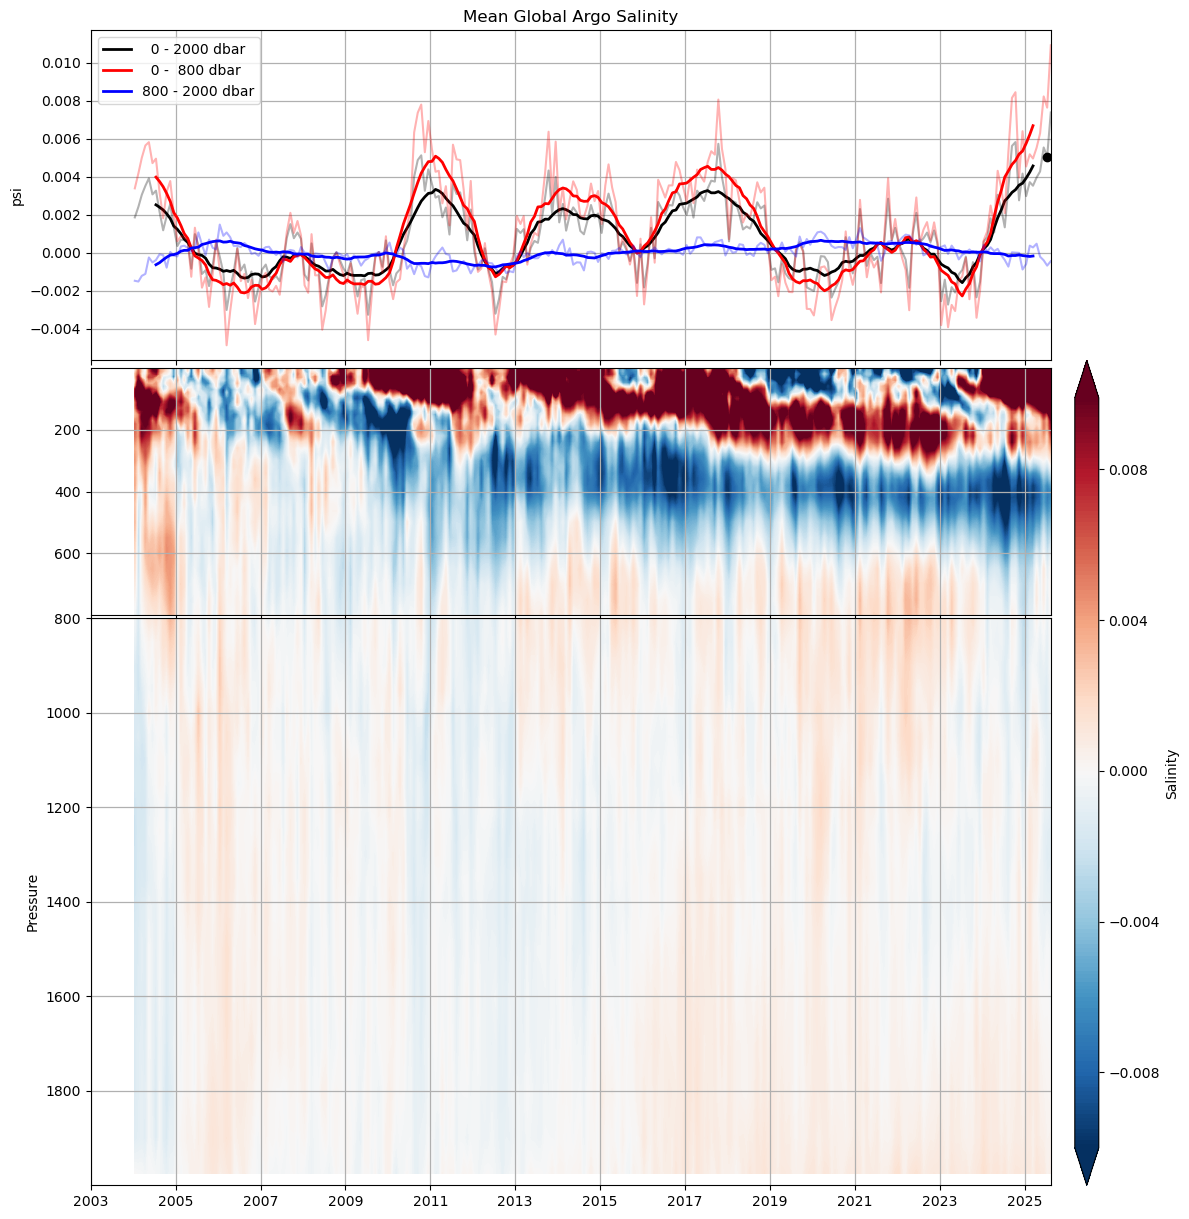

In [18]:
Tseries=DC_salt_anom_LLwmean
Tseries_rolling=DC_salt_anom_LLwmean_rolling

fig, ax = plt.subplots(3,1,figsize = (12,15),sharex=True)

# Mean values
ax[0].plot(Tseries.time,
           Tseries.sel(pre=slice(0,2000)).mean("pre"),color='k',alpha=0.3)
ax[0].plot(Tseries_rolling.time,
           Tseries_rolling.sel(pre=slice(0,2000)).mean("pre"),linewidth=2,color='k',  label= '  0 - 2000 dbar')
ax[0].plot(Tseries.time[-2],
           Tseries.sel(pre=slice(0,2000)).mean("pre")[-2],'ko')

ax[0].plot(Tseries.time,
           Tseries.sel(pre=slice(0,800)).mean("pre"),color='r',alpha=0.3)
ax[0].plot(Tseries_rolling.time,
           Tseries_rolling.sel(pre=slice(0,800)).mean("pre"),linewidth=2,color='r' ,  label= '  0 -  800 dbar')

ax[0].plot(Tseries.time,
           Tseries.sel(pre=slice(800,2000)).mean("pre"),color='b',alpha=0.3)
ax[0].plot(Tseries_rolling.time,
           Tseries_rolling.sel(pre=slice(800,2000)).mean("pre"),linewidth=2,color='b',label= '800 - 2000 dbar')

ax[0].grid(linestyle='-', linewidth=.9)
ax[0].set_position(Posiciones[0])
ax[0].legend()
ax[0].set_ylabel('psi')
ax[0].set_title('Mean Global Argo Salinity')


ax[1].contourf(Tseries.time, Tseries.sel(pre=slice(0,800)).pre, Tseries.sel(pre=slice(0,800)).transpose(),
               cmap='RdBu_r',
               levels=np.arange(-0.01,.01,0.0001),extend='both')
ax[1].invert_yaxis()
ax[1].grid(linestyle='-', linewidth=.9)
ax[1].set_ylim(0,800)
ax[1].invert_yaxis()
ax[1].set_yticks([200,400,600])
ax[1].grid(linestyle='-', linewidth=.9)
ax[1].set_position(Posiciones[1])

cntr2 = ax[2].contourf(Tseries.time, Tseries.sel(pre=slice(800,2000)).pre, 
                      Tseries.sel(pre=slice(800,2000)).transpose(),
                      cmap='RdBu_r',
                      levels=np.arange(-0.01,.01,0.0001),extend='both')
ax[2].invert_yaxis()
ax[2].grid(linestyle='-', linewidth=.9)
ax[2].set_position(Posiciones[2])
ax[2].set_ylim(800,2000)
ax[2].invert_yaxis()
ax[2].set_yticks([800,1000,1200,1400,1600,1800])
ax[2].grid(linestyle='-', linewidth=.9)
ax[2].set_position(Posiciones[2])
ax[2].set_ylabel('Pressure')

# Adding the colorbar
cbaxes = fig.add_axes([0.92, 0.1, 0.02, 0.55])  
cb = fig.colorbar(cntr2, cax=cbaxes);
cbaxes.set_yticks([-0.008, -0.004,  0, 0.004, .008])
cbaxes.set_ylabel('Salinity')

# xtick Labels
ax[0].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));
ax[1].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));
ax[2].set_xticks(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN'));

ax[2].set_xticklabels(pd.date_range(start="2003-01-01", end="2025-01-01",freq='2YS-JAN').strftime('%Y'));

fig.savefig("Poster_GlobalRGAnalisis_SSection.svg", format="svg")


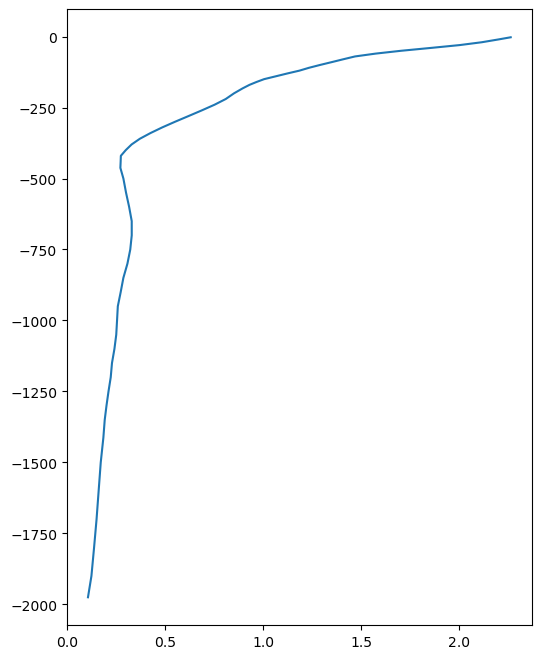

In [19]:
Tseries=DC_temp_LLwmean
DslopeS= np.zeros((Tseries.pre.shape[0]))
DslopeS.fill(np.nan)


for ipre in range(0,58):
    z = np.polyfit(Tseries.time.astype(np.int64),Tseries.sel(pre=Tseries.pre[ipre]), 1)
    linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
    DslopeS[ipre]=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo

fig, ax = plt.subplots(figsize = (6,8))
ax.plot(DslopeS,-Tseries.pre);


## Spatial variability in trends

In [20]:
pre1=0
pre2=2000

DC_temp_Pwmean = DC_temp.sel(pre=slice(pre1,pre2)).weighted(weightsPre).mean("pre")
DC_salt_Pwmean = DC_salt.sel(pre=slice(pre1,pre2)).weighted(weightsPre).mean("pre")

DC_temp_anom_Pwmean = DC_temp_anom.sel(pre=slice(pre1,pre2)).weighted(weightsPre).mean("pre")
DC_salt_anom_Pwmean = DC_salt_anom.sel(pre=slice(pre1,pre2)).weighted(weightsPre).mean("pre")

In [21]:
Zdata=DC_temp_anom_Pwmean

DslopeS= np.zeros((Zdata.shape[1],Zdata.shape[2]))
DslopeS.fill(np.nan)

for ilat in range(0,Zdata.shape[1]):
    ilat
    for ilon in range(0,Zdata.shape[2]):
        z = np.polyfit(Zdata.time.astype(np.int64),Zdata[:,ilat,ilon], 1)
    #linearf = z[0] * Tseries.time.astype(np.int64) + z[1]
        DslopeS[ilat,ilon]=z[0]/1.e-9*24*3600*365*100 #paso a C por siglo



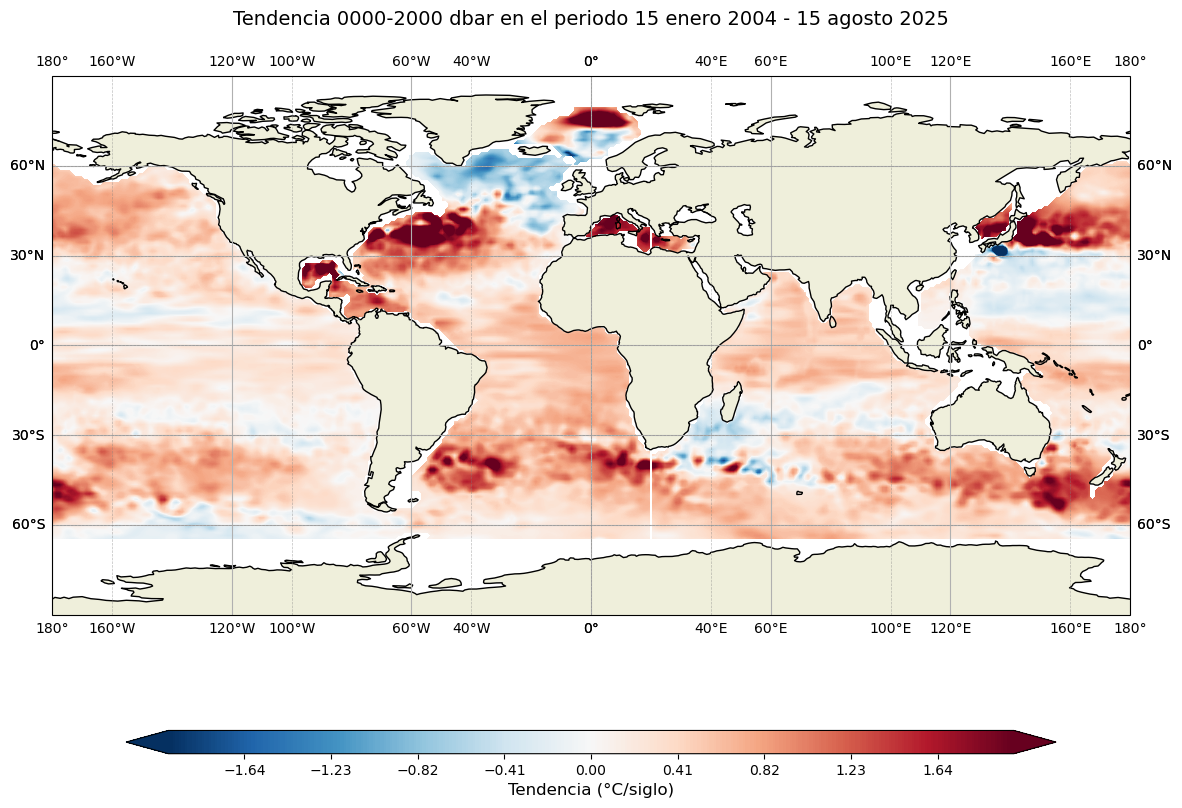

In [22]:
escalaLand='110m'
niveles=np.arange(-2,2+0.01,0.01)
nivelesC=np.arange(-2,3,1)

fig = plt.figure(figsize=(15,10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

land = cartopy.feature.NaturalEarthFeature('physical', 
                'land', edgecolor='k', scale = escalaLand ,
                facecolor=cfeature.COLORS['land'])

ax.add_feature(cartopy.feature.LAND.with_scale('110m'))
ax.add_feature(cartopy.feature.COASTLINE.with_scale('110m'), edgecolor='black')


cm=ax.contourf(Zdata.lon.values,Zdata.lat.values, DslopeS, levels=niveles,
               transform = ccrs.PlateCarree(),
               cmap = plt.cm.RdBu.reversed(),
               vmin = niveles[0],vmax = niveles[-1],extend='both')


ax.gridlines(draw_labels=True, x_inline=False, y_inline=False);

cbar=fig.colorbar(cm,ax=ax,extend='both',orientation='horizontal',shrink=.8,aspect=40)
#cbar=fig.colorbar(cm,ax=ax, location='bottom', shrink=.8, ticks=nivelesC)
cbar.set_label('Tendencia (°C/siglo)', fontsize=12)

gd=ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, linewidth=.5, color='gray', alpha=0.5, linestyle='--',x_inline=False, y_inline=False)
gd.ylocator = mticker.FixedLocator([-60,-30,0,30,60])
gd.xlocator = mticker.FixedLocator([-160, -100, -40,0,40,100,160])

#gd.left_labels = False
#gd.top_labels = False

ax.set_xlim([-180,180])
ax.set_ylim([-90, 90])

ax.set_title('Tendencia '+"%04d-%04d dbar "%(pre1,pre2)+'en el periodo '+Zdata.time[0].dt.strftime("%d %B %Y").values+' - '+Zdata.time[-1].dt.strftime("%d %B %Y").values+'\n',fontsize=14);

fig.savefig("Poster_GlobalRGAnalisis_TTrend.svg", format="svg")
